# Lab 4.05 - Bivariate Analysis of Qualitative Data


In [1]:
# Importing the necessary packages
import numpy as np                                  # "Scientific computing"
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Data Frame
from pandas.api.types import CategoricalDtype

import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic diagram
import seaborn as sns                               # Advanced data visualisation

## Exercise 5 - Survey of Australian Students

Load the data file data/survey.csv. It contains the result of a survey of students from an Australian university.

We want to investigate the relationship between some discrete (nominal or ordinal) variables in this dataset. For any pairs of variables listed below, follow these steps:

* First, think about what exactly you expect for the given combination of variables.
* Make a frequency table for the two variables. The (presumably) independent variable comes first.
* Plot a graph visualizing the relationship between the two variables.
- Looking at the chart, do you expect a rather high or rather low value for the $\chi^2$ statistic? Why?
* Run the $\chi^2$ test to determine whether there is a relationship between the two variables. Calculate the $\chi^2$ statistic, the critical limit $g$ and the $p$ value, each for significance level $\alpha = 0.05$.
* Should we accept or reject the null hypothesis? What exactly does that mean for the relationship between the two variables? In other words, formulate an answer to the research question.
* Calculate Cramér's V. Do you come to a similar conclusion as with the $\chi^2$ test?


The variables to be investigated:

| Independent variabele          | Dependent variabele                        |
|:------------------------------ |:-------------------------------------------|
| `Exer` (practicing sports)     | `Smoke`                                    |
| `Sex` (gender)                 | `Smoke`                                    |
| `W.Hnd` (dominant hand)        | `Fold` (top hand when you cross your arms) |
| `Sex`                          | `W.Hnd`                                    |

Results of the main calculations (rounded up to 3 decimal places):

- `Exer/Smoke`: χ² ≈ 5.489, g ≈ 12.592, p ≈ 0.483
- `W.Hnd/Fold`: χ² ≈ 1.581, g ≈ 5.992, p ≈ 0.454
- `Sex/Smoke`: χ² ≈ 3.554, g ≈ 7.815, p ≈ 0.314
- `Sex/W.Hnd`: χ² ≈ 0.236, g ≈ 3.842, p ≈ 0.627

Read the dataset. **Be careful!** The `read_csv()` function does not handle missing values in this dataset correctly. Missing values are represented by the string "NA", which is automatically detected by `read_csv()` as a missing value. However, it will also convert the value 'None' in the column 'Exer' to a missing value, which is not correct. To prevent this, set the parameters `na_values` to the *only* valid missing value "NA" and `keep_default_na` to `False` when calling `read_csv()`. This way, the value 'None' will be read as a valid value in the 'Exer' column.

In [80]:
dfathletes = pd.read_csv("https://raw.githubusercontent.com/HoGentTIN/dsai-labs/refs/heads/main/data/survey.csv")
dfathletes

,Unnamed: 0,Sex,Wr.Hnd,NW.Hnd,W.Hnd,Fold,Pulse,Clap,Exer,Smoke,Height,M.I,Age
0,1,Female,18.5,18.0,Right,R on L,92.0,Left,Some,Never,173.0,Metric,18.250
1,2,Male,19.5,20.5,Left,R on L,104.0,Left,NaN,Regul,177.8,Imperial,17.583
2,3,Male,18.0,13.3,Right,L on R,87.0,Neither,NaN,Occas,NaN,NaN,16.917
3,4,Male,18.8,18.9,Right,R on L,NaN,Neither,NaN,Never,160.0,Metric,20.333
4,5,Male,20.0,20.0,Right,Neither,35.0,Right,Some,Never,165.0,Metric,23.667
...,...,...,...,...,...,...,...,...,...,...,...,...,...
232,233,Female,18.0,18.0,Right,L on R,85.0,Right,Some,Never,165.1,Imperial,17.667
233,234,Female,18.5,18.0,Right,L on R,88.0,Right,Some,Never,160.0,Metric,16.917
234,235,Female,17.5,16.5,Right,R on L,NaN,Right,Some,Never,170.0,Metric,18.583
235,236,Male,21.0,21.5,Right,R on L,90.0,Right,Some,Never,183.0,Metric,17.167


What are the different values for Exer and Smoke?  
Change both variables to ordinal variables with a specific order.

In [81]:
dfathletes['Exer'].value_counts()

,count
Exer,
Freq,115
Some,98


In [82]:
dfathletes['Smoke'].value_counts()

,count
Smoke,
Never,189
Occas,19
Regul,17
Heavy,11


In [83]:
# dfathletes['Exer'].value_counts()
dfathletes['Exer'] = dfathletes['Exer'].fillna('Never')
dfathletes['Smoke'] = dfathletes['Smoke'].fillna('Never')
dfathletes

,Unnamed: 0,Sex,Wr.Hnd,NW.Hnd,W.Hnd,Fold,Pulse,Clap,Exer,Smoke,Height,M.I,Age
0,1,Female,18.5,18.0,Right,R on L,92.0,Left,Some,Never,173.0,Metric,18.250
1,2,Male,19.5,20.5,Left,R on L,104.0,Left,Never,Regul,177.8,Imperial,17.583
2,3,Male,18.0,13.3,Right,L on R,87.0,Neither,Never,Occas,NaN,NaN,16.917
3,4,Male,18.8,18.9,Right,R on L,NaN,Neither,Never,Never,160.0,Metric,20.333
4,5,Male,20.0,20.0,Right,Neither,35.0,Right,Some,Never,165.0,Metric,23.667
...,...,...,...,...,...,...,...,...,...,...,...,...,...
232,233,Female,18.0,18.0,Right,L on R,85.0,Right,Some,Never,165.1,Imperial,17.667
233,234,Female,18.5,18.0,Right,L on R,88.0,Right,Some,Never,160.0,Metric,16.917
234,235,Female,17.5,16.5,Right,R on L,NaN,Right,Some,Never,170.0,Metric,18.583
235,236,Male,21.0,21.5,Right,R on L,90.0,Right,Some,Never,183.0,Metric,17.167


In [84]:
dfathletes['Smoke'].value_counts()

,count
Smoke,
Never,190
Occas,19
Regul,17
Heavy,11


In [85]:
exer_type = CategoricalDtype(categories=['Never', 'Some', 'Freq'], ordered=True)
dfathletes['Exer'] = dfathletes['Exer'].astype(exer_type)
dfathletes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237 entries, 0 to 236
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Unnamed: 0  237 non-null    int64   
 1   Sex         236 non-null    object  
 2   Wr.Hnd      236 non-null    float64 
 3   NW.Hnd      236 non-null    float64 
 4   W.Hnd       236 non-null    object  
 5   Fold        237 non-null    object  
 6   Pulse       192 non-null    float64 
 7   Clap        236 non-null    object  
 8   Exer        237 non-null    category
 9   Smoke       237 non-null    object  
 10  Height      209 non-null    float64 
 11  M.I         209 non-null    object  
 12  Age         237 non-null    float64 
dtypes: category(1), float64(5), int64(1), object(6)
memory usage: 22.7+ KB


In [86]:
smoke_type = CategoricalDtype(categories=['Never', 'Occas', 'Regul', 'Heavy'], ordered=True)
dfathletes['Smoke'] = dfathletes['Smoke'].astype(smoke_type)
dfathletes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237 entries, 0 to 236
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Unnamed: 0  237 non-null    int64   
 1   Sex         236 non-null    object  
 2   Wr.Hnd      236 non-null    float64 
 3   NW.Hnd      236 non-null    float64 
 4   W.Hnd       236 non-null    object  
 5   Fold        237 non-null    object  
 6   Pulse       192 non-null    float64 
 7   Clap        236 non-null    object  
 8   Exer        237 non-null    category
 9   Smoke       237 non-null    category
 10  Height      209 non-null    float64 
 11  M.I         209 non-null    object  
 12  Age         237 non-null    float64 
dtypes: category(2), float64(5), int64(1), object(5)
memory usage: 21.3+ KB


* Make a frequency table for the two variables. The (presumably) independent variable comes first.
* Plot a graph visualizing the relationship between the two variables.
* Looking at the chart, do you expect a rather high or rather low value for the  χ2  statistic? Why?
* Run the  χ2  test to determine whether there is a relationship between the two variables. Calculate the  χ2  statistic, the critical limit  g  and the  p  value, each for significance level  α=0.05 .
* Should we accept or reject the null hypothesis? What exactly does that mean for the relationship between the two variables? In other words, formulate an answer to the research question.
* Calculate Cramér's V. Do you come to a similar conclusion as with the  χ2  test?

The variables to be investigated:

| Independent variabele          | Dependent variabele                        |
|:------------------------------ |:-------------------------------------------|
| `Exer` (practicing sports)     | `Smoke`                                    |
| `Sex` (gender)                 | `Smoke`                                    |
| `W.Hnd` (dominant hand)        | `Fold` (top hand when you cross your arms) |
| `Sex`                          | `W.Hnd`                                    |

Results of the main calculations (rounded up to 3 decimal places):

- `Exer/Smoke`: χ² ≈ 5.489, g ≈ 12.592, p ≈ 0.483
- `W.Hnd/Fold`: χ² ≈ 1.581, g ≈ 5.992, p ≈ 0.454
- `Sex/Smoke`: χ² ≈ 3.554, g ≈ 7.815, p ≈ 0.314
- `Sex/W.Hnd`: χ² ≈ 0.236, g ≈ 3.842, p ≈ 0.627

Exer/Smoke: χ² ≈ 5.489, g ≈ 12.592, p ≈ 0.483

In [87]:
observed = pd.crosstab(dfathletes['Exer'], dfathletes['Smoke'])
observed

Smoke,Never,Occas,Regul,Heavy
Exer,,,,
Never,19,3,1,1
Some,84,4,7,3
Freq,87,12,9,7


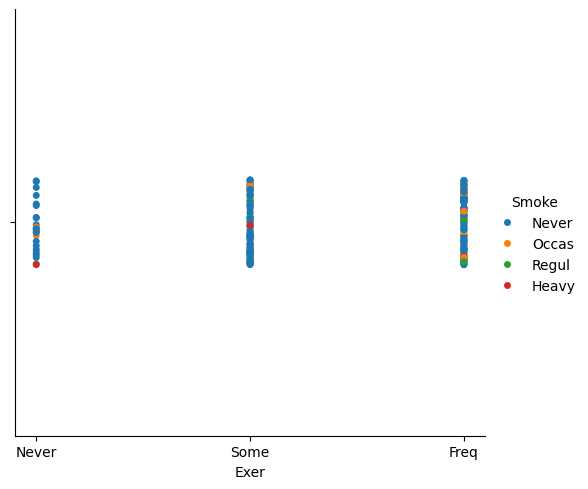

In [88]:
sns.catplot(data=dfathletes, x='Exer', hue='Smoke')

<Axes: ylabel='Exer'>

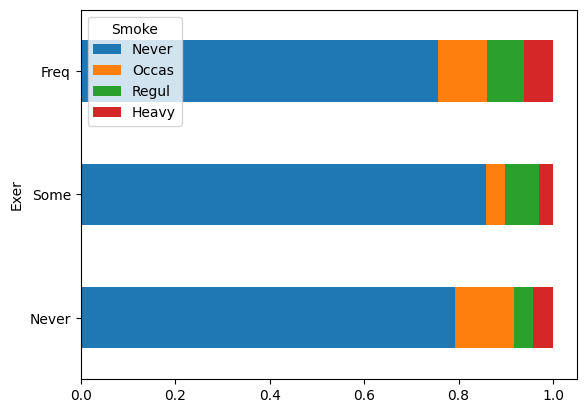

In [89]:
observed_p = pd.crosstab(dfathletes['Exer'], dfathletes['Smoke'], normalize='index')
observed_p.plot(kind='barh', stacked=True)

In [90]:
stats.contingency.association(observed, method='cramer')

0.10705564379033634

In [91]:
# Stap 1
# H0: Er is geen verband tussen Exercise en Smoke
# H1: Er is wel een verband ""

# Stap 2
alpha = 0.05

In [97]:
# Step 3: test stat chi2 (tabel bevat beperkt aantal mogelijke waarden op X en Y as)
# Step 4: crit value
observed = pd.crosstab(dfathletes['Exer'], dfathletes['Smoke'])
chi2, p, degrees_of_freedom, expected = stats.chi2_contingency(observed)
g = stats.chi2.isf(0.05, df=degrees_of_freedom)

print("Chi-squared      : %.4f" % chi2)
print("Degrees of freedom      : %.4f" % degrees_of_freedom)
print("P-value      : %.4f" % p)
print("Critical g value      : %.4f" % g)

Chi-squared      : 5.4325
Degrees of freedom      : 6.0000
P-value      : 0.4897
Critical g value      : 12.5916


In [96]:
# Step 5 Chi2 < crit value g -> niet genoeg om H0 te verwerpen
# P > alpha -> idem dito



W.Hnd/Fold: χ² ≈ 1.581, g ≈ 5.992, p ≈ 0.454

In [49]:
observed_p

Smoke,Never,Occas,Regul,Heavy
Exer,,,,
Never,0.791667,0.125000,0.041667,0.041667
Some,0.857143,0.040816,0.071429,0.030612
Freq,0.756522,0.104348,0.078261,0.060870


Sex/Smoke: χ² ≈ 3.554, g ≈ 7.815, p ≈ 0.314

Sex/W.Hnd: χ² ≈ 0.236, g ≈ 3.842, p ≈ 0.627